In [10]:
import os
import shutil

# ── All paths are relative to project root (one level up from notebooks/) ──
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Project root: {ROOT}")

folders = [
    os.path.join(ROOT, "data/raw"),
    os.path.join(ROOT, "data/processed"),
    os.path.join(ROOT, "compliance_docs"),
    os.path.join(ROOT, "outputs/eda"),
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"  ✓ {os.path.relpath(folder, ROOT)}/")

print("\n✓ Folder structure ready")


Project root: c:\Users\nethr\UCD Spring\ML\Project\ML_SYS_DEP
  ✓ data\raw/
  ✓ data\processed/
  ✓ compliance_docs/
  ✓ outputs\eda/

✓ Folder structure ready


In [11]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

print("✓ Imports done")


✓ Imports done


In [12]:
import os
from dotenv import load_dotenv

from huggingface_hub import hf_hub_download
from datasets import load_dataset, Dataset, DatasetDict

load_dotenv(os.path.join(ROOT, "secrets.env")) # loads HF_TOKEN into environment
HF_TOKEN = os.getenv("HF_TOKEN")

assert HF_TOKEN and HF_TOKEN.startswith("hf_"), "HF_TOKEN missing or invalid"

In [13]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].filter(lambda x: x["language"] == "en").to_pandas()
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem ...","Thank you for reaching out, <name>. We are aware of the outage affecting the...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
1,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am re...",Thank you for your inquiry. Our products support integration with Amazon Ale...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reac...",We appreciate you reaching out with your billing questions. The billing peri...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
3,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching ou...","Thank you for your inquiry. Our product supports integration with major CRM,...",Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
4,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I ...",Thank you for your inquiry. Please specify which product you are interested ...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [14]:
# Normalise whitespace/encoding in queue column
df["queue"] = df["queue"].str.replace("\xa0", " ").str.strip()
df["priority"] = df["priority"].str.lower().str.strip()

# ── HARD RULE: merge Technical Support + Product Support → IT Support ──
df["queue"] = df["queue"].replace({
    "Technical Support": "Technical & IT Support",
    "Product Support":   "Technical & IT Support",
    "IT Support":        "Technical & IT Support",
})

# Keep English only
df = df[df["language"] == "en"].copy()

# Drop rows missing critical columns
df = df.dropna(subset=["subject", "body", "queue", "priority"])

# Build unified text field
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df["text"] = df["text"].str.strip()

print(f"Dataset shape      : {df.shape}")
print(f"\nQueue distribution :\n{df['queue'].value_counts()}")
print(f"\nPriority distribution :\n{df['priority'].value_counts()}")


Dataset shape      : (24621, 17)

Queue distribution :
queue
Technical & IT Support             14616
Customer Service                    3755
Billing and Payments                2543
Returns and Exchanges               1216
Service Outages and Maintenance      996
Sales and Pre-Sales                  692
Human Resources                      468
General Inquiry                      335
Name: count, dtype: int64

Priority distribution :
priority
medium    10134
high       9454
low        5033
Name: count, dtype: int64


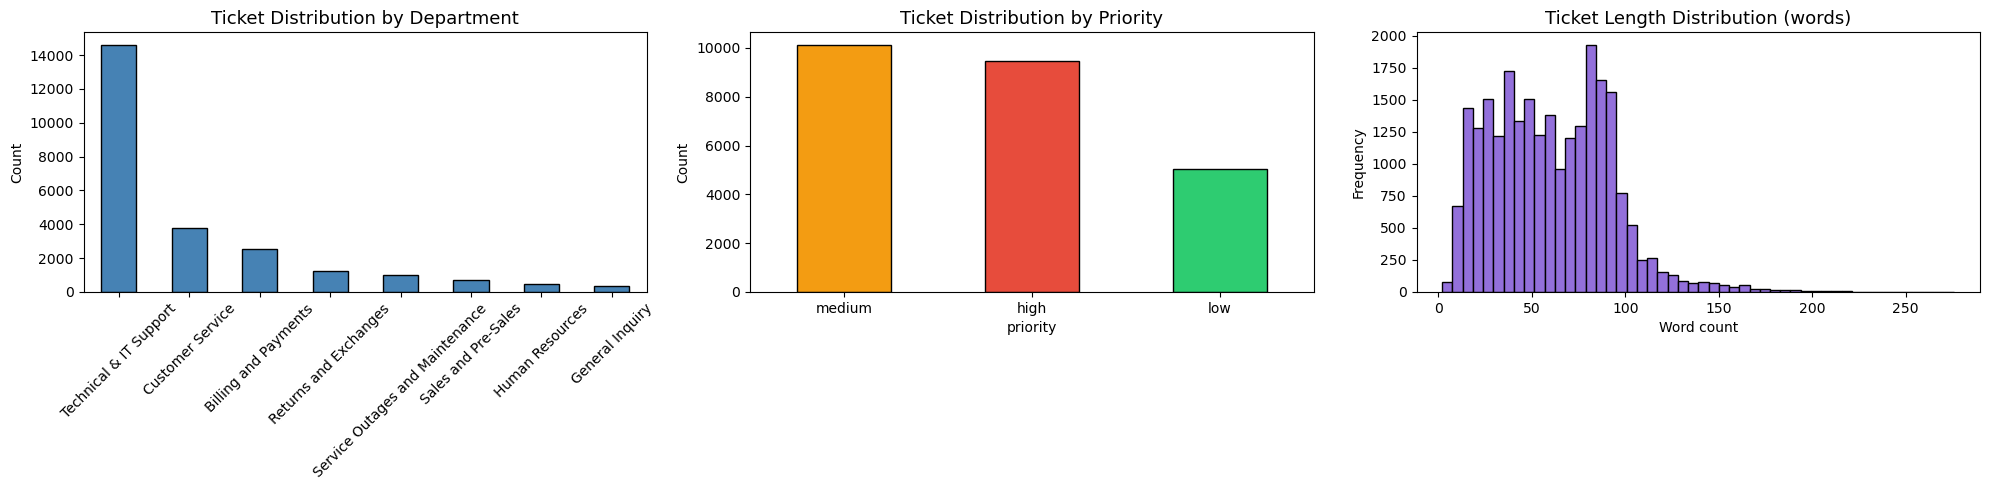

✓ EDA saved to eda_overview.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Queue distribution
queue_counts = df["queue"].value_counts()
queue_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Ticket Distribution by Department", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

# Priority distribution
priority_counts = df["priority"].value_counts()
colors = {"high": "#e74c3c", "medium": "#f39c12", "low": "#2ecc71"}
priority_counts.plot(kind="bar", ax=axes[1],
                     color=[colors.get(p, "grey") for p in priority_counts.index],
                     edgecolor="black")
axes[1].set_title("Ticket Distribution by Priority", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# Text length distribution
df["text_len"] = df["text"].str.split().str.len()
axes[2].hist(df["text_len"].clip(upper=300), bins=50, color="mediumpurple", edgecolor="black")
axes[2].set_title("Ticket Length Distribution (words)", fontsize=13)
axes[2].set_xlabel("Word count")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "outputs/eda/eda_overview.png"), dpi=150)
plt.show()
print("✓ EDA saved to eda_overview.png")


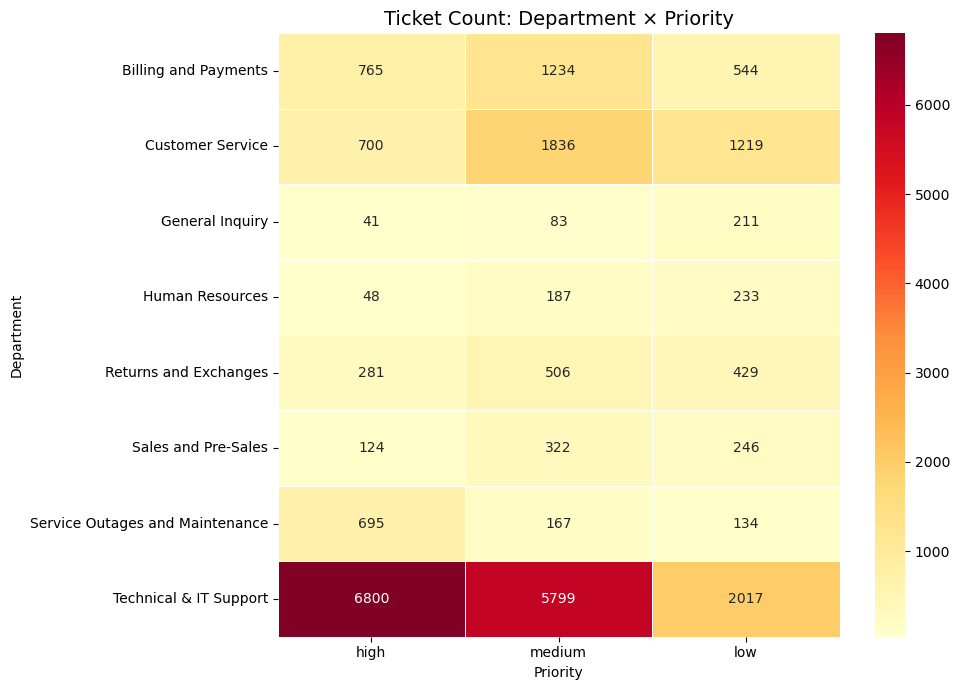

✓ Heatmap saved to eda_heatmap.png


In [16]:
heatmap_data = df.groupby(["queue", "priority"]).size().unstack(fill_value=0)
heatmap_data = heatmap_data[["high", "medium", "low"]]  # fix column order

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Ticket Count: Department × Priority", fontsize=14)
plt.ylabel("Department")
plt.xlabel("Priority")
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "outputs/eda/eda_heatmap.png"), dpi=150)
plt.show()
print("✓ Heatmap saved to eda_heatmap.png")


In [17]:
# Stratify on combined queue+priority to preserve class balance in both splits
df["strat_key"] = df["queue"] + "|||" + df["priority"]

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["strat_key"],
)

train_df = train_df.drop(columns=["strat_key"]).reset_index(drop=True)
test_df  = test_df.drop(columns=["strat_key"]).reset_index(drop=True)
df       = df.drop(columns=["strat_key"])

print(f"Train size : {len(train_df)}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test  size : {len(test_df)}   ({len(test_df)/len(df)*100:.1f}%)")
print(f"\nTrain queue distribution:\n{train_df['queue'].value_counts()}")
print(f"\nTest  queue distribution:\n{test_df['queue'].value_counts()}")

train_df.to_csv(os.path.join(ROOT, "data/processed/train.csv"), index=False)
test_df.to_csv(os.path.join(ROOT, "data/processed/test.csv"),  index=False)
print("✓ Saved train.csv and test.csv to data/processed/")


Train size : 17234  (70.0%)
Test  size : 7387   (30.0%)

Train queue distribution:
queue
Technical & IT Support             10231
Customer Service                    2628
Billing and Payments                1780
Returns and Exchanges                851
Service Outages and Maintenance      697
Sales and Pre-Sales                  484
Human Resources                      328
General Inquiry                      235
Name: count, dtype: int64

Test  queue distribution:
queue
Technical & IT Support             4385
Customer Service                   1127
Billing and Payments                763
Returns and Exchanges               365
Service Outages and Maintenance     299
Sales and Pre-Sales                 208
Human Resources                     140
General Inquiry                     100
Name: count, dtype: int64
✓ Saved train.csv and test.csv to data/processed/


In [18]:
COMPLIANCE_DIR = os.path.join(ROOT, "compliance_docs")

print("=" * 65)
print("COMPLIANCE DOCUMENT VERIFICATION")
print("=" * 65)

for fname in sorted(os.listdir(COMPLIANCE_DIR)):
    if not fname.endswith(".txt"):
        continue
    fpath = os.path.join(COMPLIANCE_DIR, fname)
    with open(fpath, encoding="utf-8") as f:
        text = f.read()

    is_priority_doc = "Priority_Escalation_Criteria" in fname

    if is_priority_doc:
        has_high     = "PRIORITY: HIGH"   in text
        has_medium   = "PRIORITY: MEDIUM" in text
        has_low      = "PRIORITY: LOW"    in text
        has_examples = "Representative"   in text
        status = "✓" if (has_high and has_medium and has_low and has_examples) else "✗"
        print(f"  {status}  {fname:<45}  [PRIORITY DOC]  H:{has_high} M:{has_medium} L:{has_low}")
    else:
        has_overview  = "OVERVIEW"                in text
        has_routing   = "ROUTING DECISION GUIDANCE" in text
        has_examples  = "REPRESENTATIVE EXAMPLES"  in text
        no_priority   = "PRIORITY: HIGH" not in text
        status = "✓" if (has_overview and has_routing and has_examples and no_priority) else "✗"
        print(f"  {status}  {fname:<45}  [DEPT DOC]  Overview:{has_overview} Routing:{has_routing} NoPriority:{no_priority}")

print("\n" + "=" * 65)
print(f"Train set  → {len(train_df):>6} rows  saved to train.csv")
print(f"Test set   → {len(test_df):>6} rows  saved to test.csv")
print(f"Compliance → 9 docs (8 dept + 1 priority)")
print("=" * 65)

COMPLIANCE DOCUMENT VERIFICATION
  ✓  Billing_and_Payments.txt                       [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Customer_Service.txt                           [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  General_Inquiry.txt                            [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Human_Resources.txt                            [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Priority_Escalation_Criteria.txt               [PRIORITY DOC]  H:True M:True L:True
  ✓  Returns_and_Exchanges.txt                      [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Sales_and_Pre-Sales.txt                        [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Service_Outages_and_Maintenance.txt            [DEPT DOC]  Overview:True Routing:True NoPriority:True
  ✓  Technical & IT Support.txt                     [DEPT DOC]  Overview:True Routing:True NoPriority:True

Train set  →  17234 r